# Futsal Sentiment Training Experiments

This notebook is for experimentation and comparison.

## Goals
- Inspect processed dataset quality
- Reproduce baseline model
- Run a small hyperparameter search
- Keep a clear record of selected configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

project_root = Path.cwd().resolve()
if not (project_root / "app").exists():
    project_root = project_root.parent

processed_path = project_root / "app" / "data" / "processed" / "futsal_reviews_dataset_processed.csv"
processed_path

PosixPath('/home/aashis-rijal/Desktop/futsal/futsal booking/ml/app/data/processed/futsal_reviews_dataset_processed.csv')

In [2]:
df = pd.read_csv(processed_path)

df = df.dropna(subset=["review", "label"]).copy()
df["review"] = df["review"].astype(str)
df["label"] = df["label"].astype(int)
df["review_len"] = df["review"].str.len()
df["token_count"] = df["review"].str.split().str.len()

print(f"Rows: {len(df)}")
print(df[["review", "label"]].head(5))

Rows: 1148
                                              review  label
0  well spacious court and proper lighting setup ...      1
1  to be honest facilities were not clean at all ...      0
2  frankly speaking spacious court and proper lig...      1
3  overall very professional staff and management...      1
4  to be honest facilities were outdated and not ...      0


label
Negative    574
Positive    574
Name: count, dtype: int64


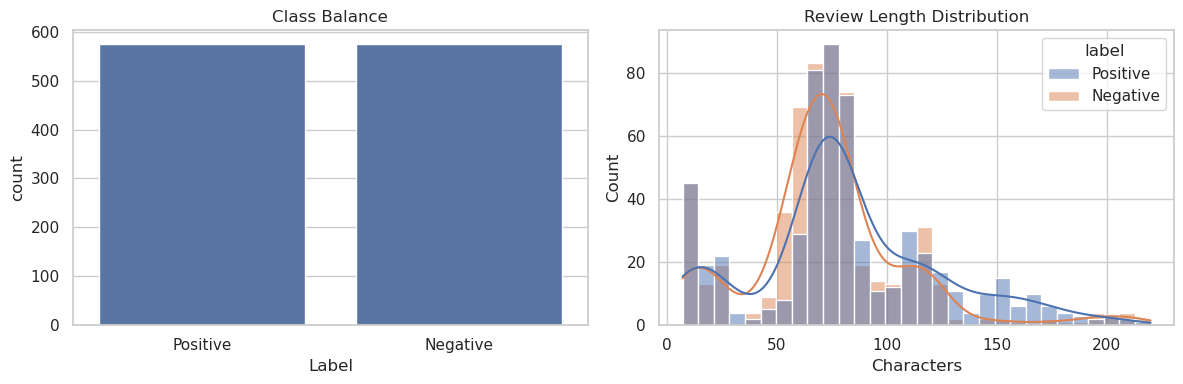

In [3]:
label_names = {0: "Negative", 1: "Positive"}
class_counts = df["label"].value_counts().sort_index().rename(index=label_names)
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=df["label"].map(label_names), ax=axes[0])
axes[0].set_title("Class Balance")
axes[0].set_xlabel("Label")

sns.histplot(data=df, x="review_len", hue=df["label"].map(label_names), bins=30, ax=axes[1], kde=True)
axes[1].set_title("Review Length Distribution")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

In [4]:
X = df["review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


def run_experiment(max_features: int, ngram_range: tuple[int, int], C: float) -> dict:
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = LogisticRegression(max_iter=1000, C=C)
    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
    accuracy = accuracy_score(y_test, y_pred)

    return {
        "max_features": max_features,
        "ngram_range": str(ngram_range),
        "C": C,
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
    }

In [5]:
baseline_result = run_experiment(max_features=5000, ngram_range=(1, 1), C=1.0)
baseline_result

{'max_features': 5000,
 'ngram_range': '(1, 1)',
 'C': 1.0,
 'accuracy': 0.7957,
 'precision': 0.8091,
 'recall': 0.7739,
 'f1': 0.7911}

In [6]:
experiment_grid = [
    {"max_features": 3000, "ngram_range": (1, 1), "C": 0.5},
    {"max_features": 5000, "ngram_range": (1, 1), "C": 1.0},
    {"max_features": 8000, "ngram_range": (1, 1), "C": 1.5},
    {"max_features": 5000, "ngram_range": (1, 2), "C": 1.0},
    {"max_features": 8000, "ngram_range": (1, 2), "C": 1.0},
]

results = [run_experiment(**cfg) for cfg in experiment_grid]
results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
results_df

,max_features,ngram_range,C,accuracy,precision,recall,f1
0,8000,"(1, 1)",1.5,0.8130,0.8051,0.8261,0.8155
1,8000,"(1, 2)",1.0,0.8174,0.8411,0.7826,0.8108
2,5000,"(1, 2)",1.0,0.8174,0.8411,0.7826,0.8108
3,5000,"(1, 1)",1.0,0.7957,0.8091,0.7739,0.7911
4,3000,"(1, 1)",0.5,0.7783,0.8019,0.7391,0.7692


## Conclusion Template

- Best config: `...`
- Best accuracy: `...`
- Best f1-score: `...`
- Keep this notebook for experiments; keep production training in `app/training/*.py`.
- If improved, update training scripts and retrain artifacts.